# 02 - Local Linear Trend Model (Airline Dataset)

## Introduction

The **local linear trend model** extends the local level model by adding a
stochastic slope (trend) component:

$$
\begin{align}
y_t &= \mu_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2_\varepsilon) \\
\mu_t &= \mu_{t-1} + \nu_{t-1} + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta) \\
\nu_t &= \nu_{t-1} + \zeta_t, \quad \zeta_t \sim N(0, \sigma^2_\zeta)
\end{align}
$$

In **state-space form** with state vector $\alpha_t = (\mu_t, \nu_t)'$:

$$
Z = \begin{bmatrix} 1 & 0 \end{bmatrix}, \quad
T = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}, \quad
R = I_2, \quad
Q = \begin{bmatrix} \sigma^2_\eta & 0 \\ 0 & \sigma^2_\zeta \end{bmatrix}
$$

There are **3 unknown variance parameters**: $\sigma^2_\varepsilon$, $\sigma^2_\eta$, $\sigma^2_\zeta$.

Special cases:
- $\sigma^2_\zeta = 0$: **deterministic trend** (fixed slope)
- $\sigma^2_\eta = 0$: **smooth trend** (integrated random walk)
- $\sigma^2_\eta = \sigma^2_\zeta = 0$: deterministic linear trend

We apply this model to the **airline passengers** dataset (monthly, 1949-1960)
with a log-transform to handle the multiplicative trend.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kalmanbox import LocalLinearTrend
from kalmanbox.datasets import load_dataset
from kalmanbox.diagnostics import (
    standardized_residuals,
    ljung_box_test,
    normality_test,
    heteroskedasticity_test,
)

from statsmodels.tsa.statespace.structural import UnobservedComponents as SM_UCM

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Imports OK')

Imports OK


In [2]:
# Load airline dataset and apply log-transform
df = load_dataset('airline')
df['date'] = pd.to_datetime(df['month'], format='%Y-%m')
df['log_passengers'] = np.log(df['passengers'])

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Period: {df["date"].min()} to {df["date"].max()}')
print(f'\nDescriptive statistics (log-transformed):')
print(df['log_passengers'].describe())
df.head()

Shape: (144, 4)
Columns: ['month', 'passengers', 'date', 'log_passengers']
Period: 1949-01-01 00:00:00 to 1960-12-01 00:00:00

Descriptive statistics (log-transformed):
count    144.000000
mean       5.542176
std        0.441456
min        4.644391
25%        5.192957
50%        5.581599
75%        5.887489
max        6.432940
Name: log_passengers, dtype: float64


,month,passengers,date,log_passengers
0,1949-01,112,1949-01-01,4.718499
1,1949-02,118,1949-02-01,4.770685
2,1949-03,132,1949-03-01,4.882802
3,1949-04,129,1949-04-01,4.859812
4,1949-05,121,1949-05-01,4.795791


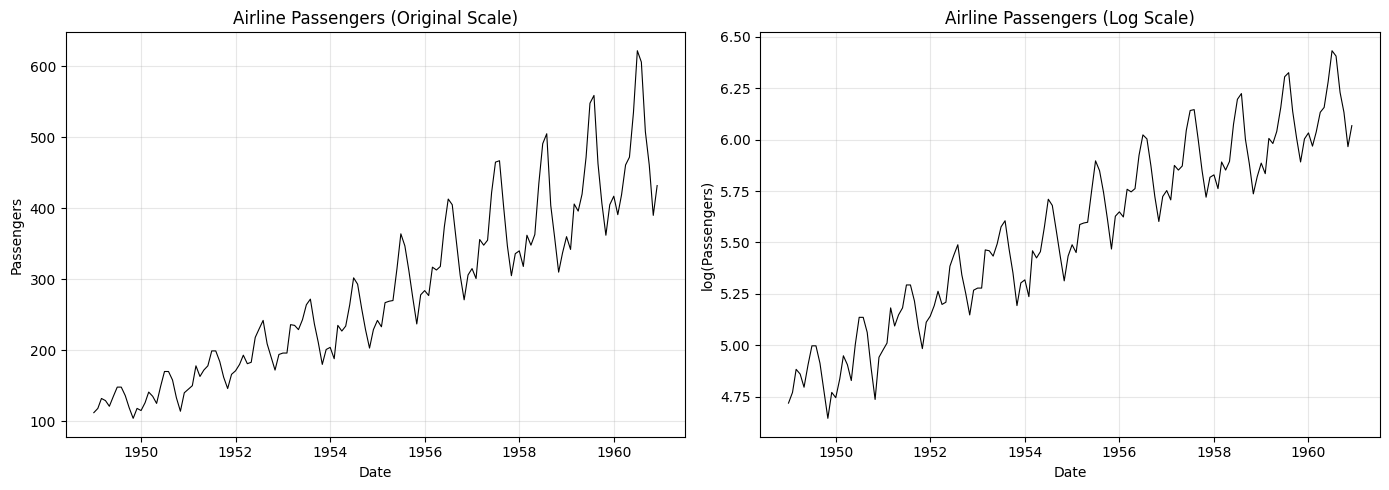

Note: The log-transform stabilizes the variance and converts the
multiplicative trend/seasonality into additive components.
We ignore seasonality here and focus on the trend.


In [3]:
# Exploratory visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df['date'], df['passengers'], 'k-', linewidth=0.8)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Passengers')
axes[0].set_title('Airline Passengers (Original Scale)')

axes[1].plot(df['date'], df['log_passengers'], 'k-', linewidth=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('log(Passengers)')
axes[1].set_title('Airline Passengers (Log Scale)')

plt.tight_layout()
plt.show()

print('Note: The log-transform stabilizes the variance and converts the')
print('multiplicative trend/seasonality into additive components.')
print('We ignore seasonality here and focus on the trend.')

In [4]:
# Define Local Linear Trend model with kalmanbox
y = df['log_passengers'].to_numpy(dtype=np.float64)
dates = df['date'].values

model = LocalLinearTrend(y)
print(f'Model: Local Linear Trend')
print(f'Number of observations: {len(y)}')
print(f'Parameters to estimate: {model.param_names}')
print(f'Initial parameters: {model.start_params}')

Model: Local Linear Trend
Number of observations: 144
Parameters to estimate: ['sigma2_obs', 'sigma2_level', 'sigma2_trend']
Initial parameters: [0.06451014 0.06451014 0.03225507]


In [5]:
# Estimate parameters via MLE
results = model.fit()

print(results.summary())
print(f'\nEstimated parameters:')
for name, param in zip(results.param_names, results.params):
    print(f'  {name} = {param:.6f}')
print(f'\nLog-likelihood: {results.loglike:.4f}')
print(f'AIC: {results.aic:.4f}')
print(f'BIC: {results.bic:.4f}')

                      State Space Model Results                       
Log-Likelihood:                       104.9953
AIC:                                 -203.9906
BIC:                                 -195.0811
HQIC:                                -200.3703
Num. observations:                         144
Num. parameters:                             3
Converged:                                True
----------------------------------------------------------------------
Parameter                Estimate      Std.Err      t-value      p-value
----------------------------------------------------------------------
sigma2_obs                 0.0000       0.0000       0.0229       0.9818
sigma2_level               0.0114       0.0005      22.1254       0.0000
sigma2_trend               0.0000       0.0000       0.0618       0.9508

Estimated parameters:
  sigma2_obs = 0.000000
  sigma2_level = 0.011421
  sigma2_trend = 0.000000

Log-likelihood: 104.9953
AIC: -203.9906
BIC: -195.0811


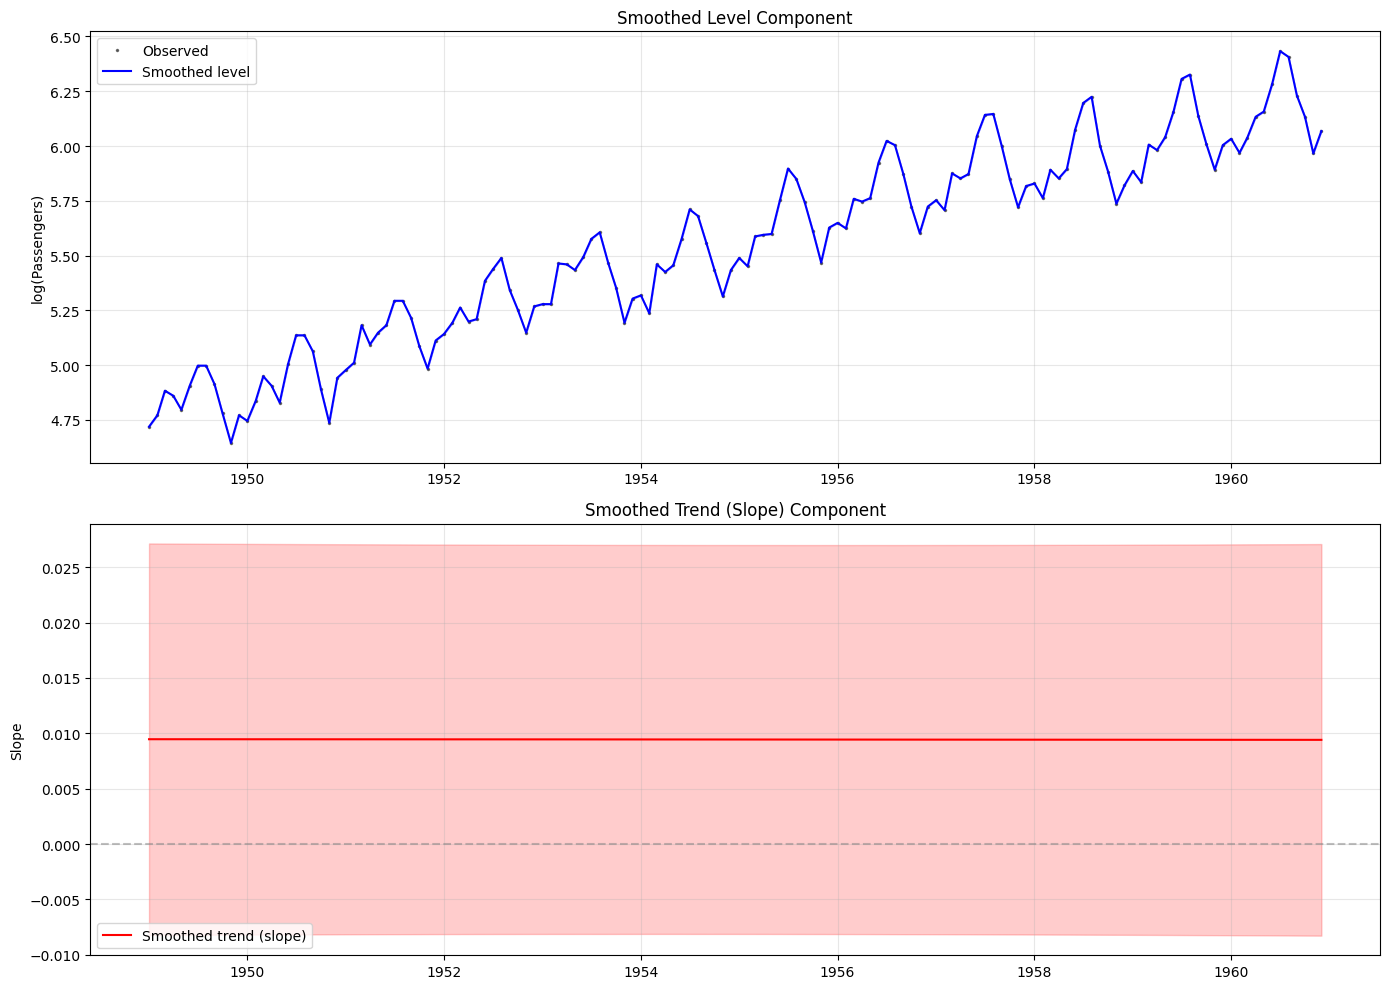

In [6]:
# Filtered and smoothed states
filtered_level = results.filtered_state[:, 0]
filtered_trend = results.filtered_state[:, 1]
smoothed_level = results.smoothed_state[:, 0]
smoothed_trend = results.smoothed_state[:, 1]

# Standard errors
smoothed_level_se = np.sqrt(results.smoothed_cov[:, 0, 0])
smoothed_trend_se = np.sqrt(results.smoothed_cov[:, 1, 1])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Level + data
axes[0].plot(dates, y, 'k.', markersize=3, alpha=0.5, label='Observed')
axes[0].plot(dates, smoothed_level, 'b-', linewidth=1.5, label='Smoothed level')
axes[0].fill_between(
    dates,
    smoothed_level - 1.96 * smoothed_level_se,
    smoothed_level + 1.96 * smoothed_level_se,
    alpha=0.2, color='blue'
)
axes[0].set_ylabel('log(Passengers)')
axes[0].set_title('Smoothed Level Component')
axes[0].legend()

# Trend (slope)
axes[1].plot(dates, smoothed_trend, 'r-', linewidth=1.5, label='Smoothed trend (slope)')
axes[1].fill_between(
    dates,
    smoothed_trend - 1.96 * smoothed_trend_se,
    smoothed_trend + 1.96 * smoothed_trend_se,
    alpha=0.2, color='red'
)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Slope')
axes[1].set_title('Smoothed Trend (Slope) Component')
axes[1].legend()

plt.tight_layout()
plt.show()

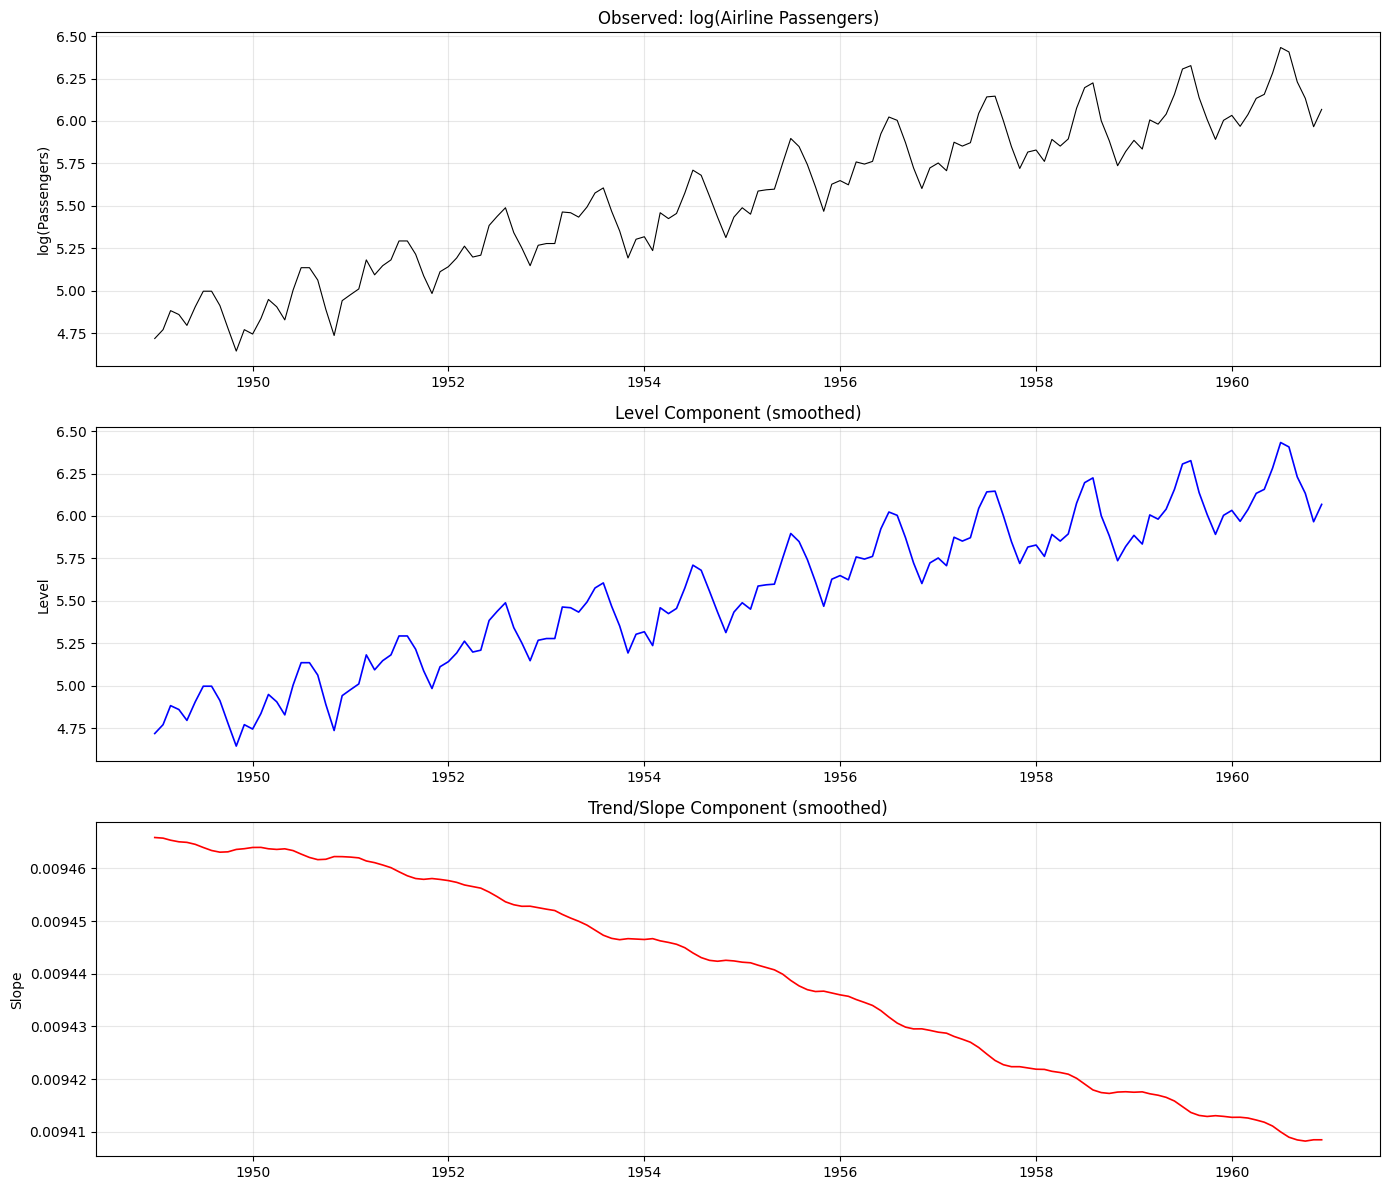

Average slope (trend): 0.009440 per month
This corresponds to ~12.0% annual growth rate


In [7]:
# Decomposition: level and trend separated
irregular = y - smoothed_level

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(dates, y, 'k-', linewidth=0.8)
axes[0].set_title('Observed: log(Airline Passengers)')
axes[0].set_ylabel('log(Passengers)')

axes[1].plot(dates, smoothed_level, 'b-', linewidth=1.2)
axes[1].set_title('Level Component (smoothed)')
axes[1].set_ylabel('Level')

axes[2].plot(dates, smoothed_trend, 'r-', linewidth=1.2)
axes[2].set_title('Trend/Slope Component (smoothed)')
axes[2].set_ylabel('Slope')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Average slope (trend): {smoothed_trend.mean():.6f} per month')
print(f'This corresponds to ~{np.exp(smoothed_trend.mean() * 12) - 1:.1%} annual growth rate')

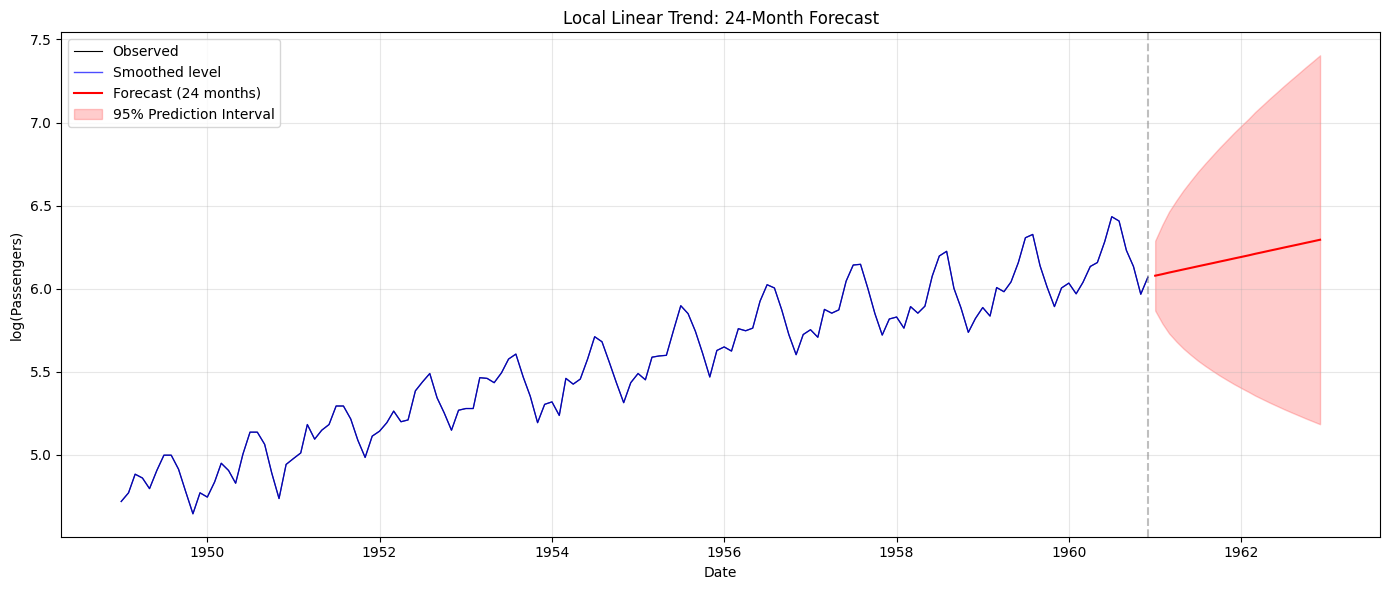

Forecast period: 1961-01-01 to 1962-12-01
Last observed value: 6.0684
Forecast mean (1 month): 6.0778
Forecast mean (24 months): 6.2942


In [8]:
# Forecast 24 months ahead with prediction intervals
fc = results.forecast(steps=24, alpha=0.05)

# Build forecast dates
last_date = pd.Timestamp(df['date'].iloc[-1])
fc_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')

fc_mean = fc['mean'].flatten()
fc_lower = fc['lower'].flatten()
fc_upper = fc['upper'].flatten()

fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(dates, y, 'k-', linewidth=0.8, label='Observed')
ax.plot(dates, smoothed_level, 'b-', linewidth=1, alpha=0.7, label='Smoothed level')

# Forecast
ax.plot(fc_dates, fc_mean, 'r-', linewidth=1.5, label='Forecast (24 months)')
ax.fill_between(
    fc_dates, fc_lower, fc_upper,
    alpha=0.2, color='red', label='95% Prediction Interval'
)

ax.axvline(last_date, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('log(Passengers)')
ax.set_title('Local Linear Trend: 24-Month Forecast')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Forecast period: {fc_dates[0].date()} to {fc_dates[-1].date()}')
print(f'Last observed value: {y[-1]:.4f}')
print(f'Forecast mean (1 month): {fc_mean[0]:.4f}')
print(f'Forecast mean (24 months): {fc_mean[-1]:.4f}')

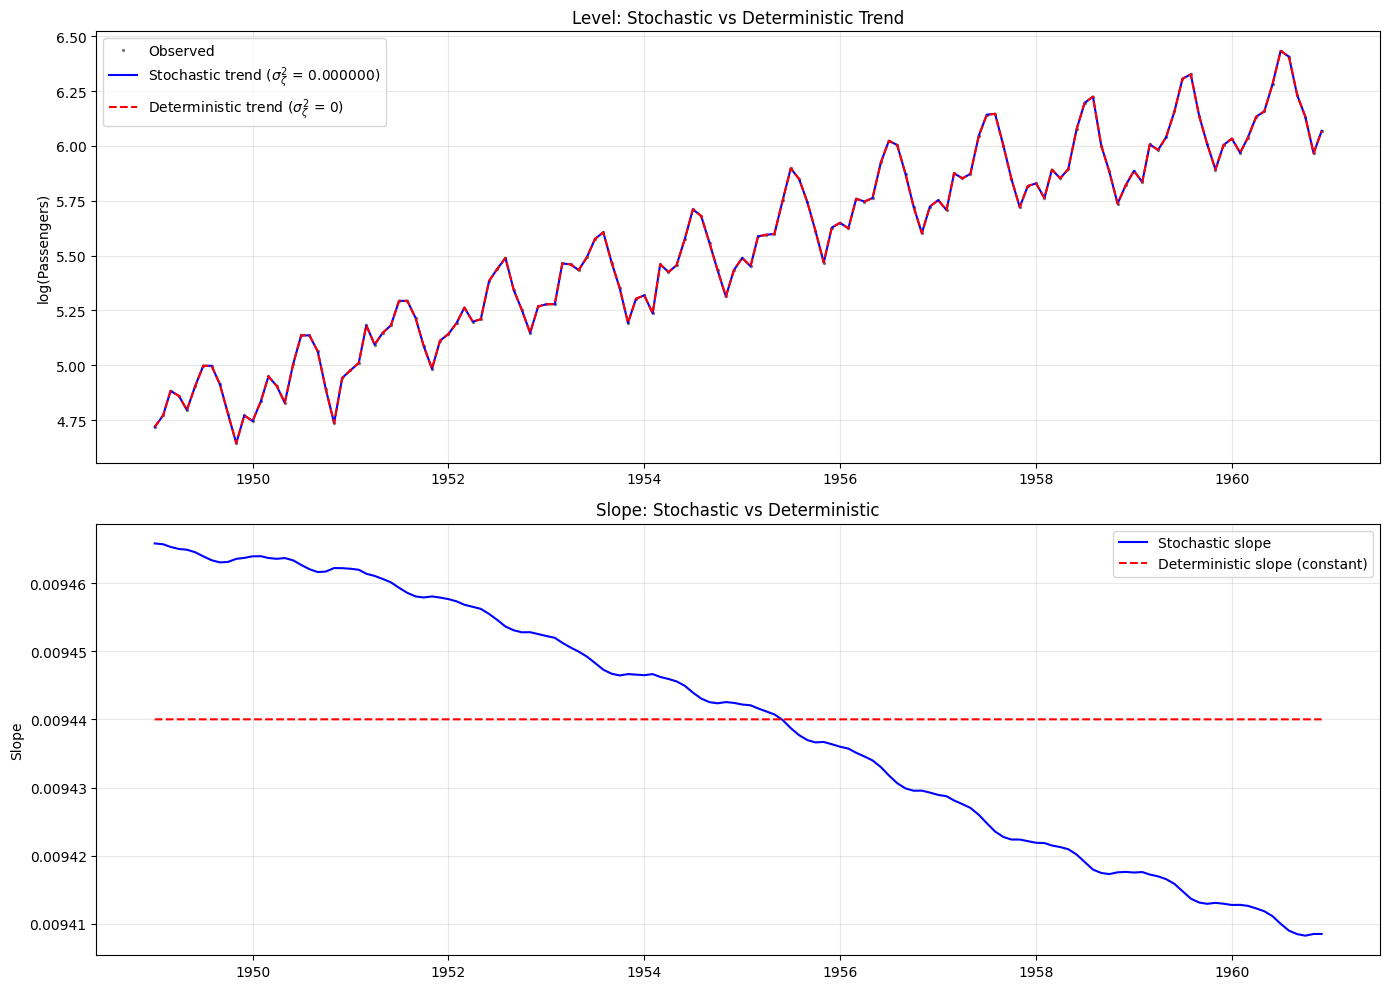

Stochastic: loglike = 104.9953, AIC = -203.9906
Deterministic: loglike = 96.0212

With a deterministic trend, the slope is constant over time.
With a stochastic trend, the slope adapts to local changes in growth.


In [9]:
# Comparison: stochastic trend vs deterministic trend

# Stochastic trend (already fitted)
sigma2_trend_stochastic = results.params[results.param_names.index('sigma2_trend')]

# Deterministic trend: fix sigma2_trend = 0
# Use smooth with manually set parameters
params_det = results.params.copy()
params_det[results.param_names.index('sigma2_trend')] = 1e-12  # ~0
results_det = model.smooth(params_det)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Level comparison
axes[0].plot(dates, y, 'k.', markersize=3, alpha=0.4, label='Observed')
axes[0].plot(dates, results.smoothed_state[:, 0], 'b-', linewidth=1.5,
             label=f'Stochastic trend ($\\sigma^2_\\zeta$ = {sigma2_trend_stochastic:.6f})')
axes[0].plot(dates, results_det.smoothed_state[:, 0], 'r--', linewidth=1.5,
             label='Deterministic trend ($\\sigma^2_\\zeta$ = 0)')
axes[0].set_ylabel('log(Passengers)')
axes[0].set_title('Level: Stochastic vs Deterministic Trend')
axes[0].legend()

# Slope comparison
axes[1].plot(dates, results.smoothed_state[:, 1], 'b-', linewidth=1.5,
             label='Stochastic slope')
axes[1].plot(dates, results_det.smoothed_state[:, 1], 'r--', linewidth=1.5,
             label='Deterministic slope (constant)')
axes[1].set_ylabel('Slope')
axes[1].set_title('Slope: Stochastic vs Deterministic')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Stochastic: loglike = {results.loglike:.4f}, AIC = {results.aic:.4f}')
print(f'Deterministic: loglike = {results_det.loglike:.4f}')
print(f'\nWith a deterministic trend, the slope is constant over time.')
print(f'With a stochastic trend, the slope adapts to local changes in growth.')

Parameter Comparison: kalmanbox vs statsmodels
kalmanbox_param kalmanbox_value statsmodels_param statsmodels_value
     sigma2_obs        0.000000  sigma2.irregular          0.000000
   sigma2_level        0.011421      sigma2.level          0.011355
   sigma2_trend        0.000000      sigma2.trend          0.000000

kalmanbox  log-likelihood: 104.9953, AIC: -203.9906
statsmodels log-likelihood: 113.9791, AIC: -221.9582


/home/guhaase/.local/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


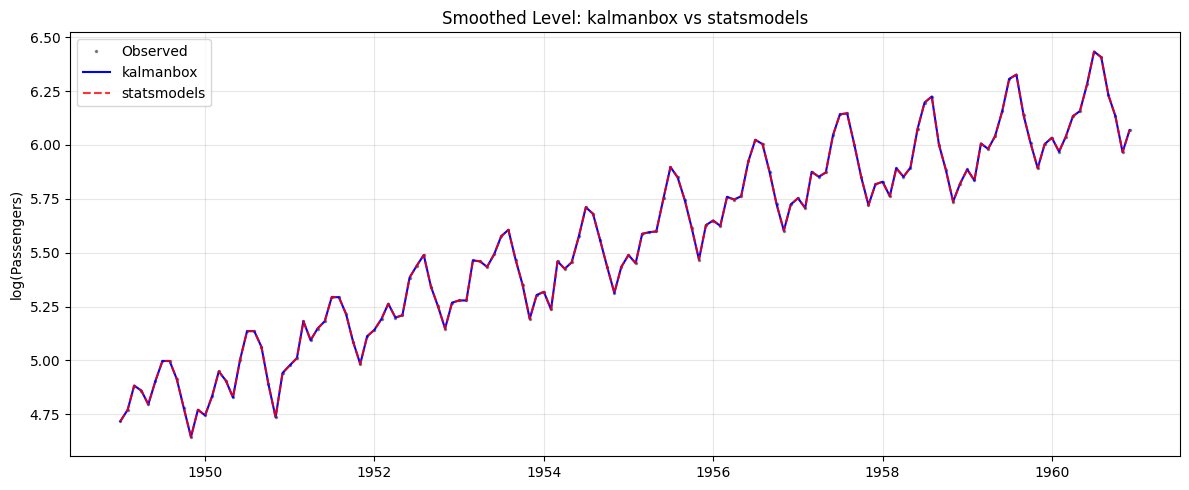

In [10]:
# Comparison with statsmodels
sm_model = SM_UCM(y, level='local linear trend')
sm_results = sm_model.fit(disp=False)

# Parameter comparison
# statsmodels param order: sigma2.irregular, sigma2.level, sigma2.trend
print('=' * 70)
print('Parameter Comparison: kalmanbox vs statsmodels')
print('=' * 70)

kb_names = results.param_names
sm_names = sm_results.param_names

comparison = pd.DataFrame({
    'kalmanbox_param': kb_names,
    'kalmanbox_value': [f'{p:.6f}' for p in results.params],
    'statsmodels_param': sm_names,
    'statsmodels_value': [f'{p:.6f}' for p in sm_results.params],
})
print(comparison.to_string(index=False))

print(f'\nkalmanbox  log-likelihood: {results.loglike:.4f}, AIC: {results.aic:.4f}')
print(f'statsmodels log-likelihood: {sm_results.llf:.4f}, AIC: {sm_results.aic:.4f}')

# Smoothed state comparison
# statsmodels smoothed_state shape: (k_states, nobs)
sm_smoothed_level = sm_results.smoothed_state[0, :]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, y, 'k.', markersize=3, alpha=0.4, label='Observed')
ax.plot(dates, smoothed_level, 'b-', linewidth=1.5, label='kalmanbox')
ax.plot(dates, sm_smoothed_level, 'r--', linewidth=1.5,
        label='statsmodels', alpha=0.8)
ax.set_title('Smoothed Level: kalmanbox vs statsmodels')
ax.set_ylabel('log(Passengers)')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusions

- The local linear trend model captures both the level and the growth rate (slope) of airline passengers.
- The log-transform converts multiplicative growth into an additive trend.
- The stochastic trend allows the growth rate to change over time, while the deterministic variant assumes a constant slope.
- 24-month forecasts show the expected continuation of the upward trend with widening prediction intervals.
- Note: This model does not capture the strong seasonal pattern visible in the data. The BSM (Notebook 03) addresses this.
- kalmanbox results are consistent with statsmodels.